# Versao 13 - Comparacao BiGRU + MHA Vs Baselines

A `versao13` precisa ser lida no mesmo protocolo das versoes anteriores: comparar a nova rede sequencial com as baselines tabulares e com as melhores redes recorrentes ja registradas no projeto.


## O que este notebook responde

A comparacao final da `versao13` precisa responder tres perguntas:

1. a arquitetura `BiGRU + MHA` melhora sobre as melhores recorrentes anteriores?
2. ela reduz o gap para `RandomForest`, `XGBoost` e `LGBM`?
3. a projecao univariada escolhida preservou informacao suficiente para competir com as abordagens anteriores?


In [1]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
PROJECT_ROOT = ROOT.parent if ROOT.name == 'versao13' else ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import versao13.pipeline_v13 as pipeline_v13

pipeline_v13 = importlib.reload(pipeline_v13)
build_metrics_table = pipeline_v13.build_metrics_table
evaluate_predictions = pipeline_v13.evaluate_predictions
export_evaluation_artifacts = pipeline_v13.export_evaluation_artifacts
fit_lgbm_baseline = pipeline_v13.fit_lgbm_baseline
fit_random_forest_baseline = pipeline_v13.fit_random_forest_baseline
fit_xgboost_baseline = pipeline_v13.fit_xgboost_baseline
load_bigru_attention_model = pipeline_v13.load_bigru_attention_model
load_bundle = pipeline_v13.load_bundle
load_split_arrays = pipeline_v13.load_split_arrays
plot_confusion_matrix_for_predictions = pipeline_v13.plot_confusion_matrix_for_predictions
predict_bigru_attention_model_classes = pipeline_v13.predict_bigru_attention_model_classes

RUN_NAME = 'classificacao_v13_bigru_mha'
RUN_DIR = PROJECT_ROOT / 'artifacts' / 'reports_v13' / RUN_NAME
MODEL_DIR = RUN_DIR / 'bigru_mha'
BASELINE_DIR = RUN_DIR / 'baselines'

PREVIOUS_METRIC_FILES = {
    'LSTM v9': PROJECT_ROOT / 'artifacts' / 'reports_v9' / 'classificacao_v9_lstm_hibrida' / 'lstm' / 'hybrid_lstm_test_metrics.json',
    'LSTM v10': PROJECT_ROOT / 'artifacts' / 'reports_v10' / 'classificacao_v10_multitarefa' / 'lstm' / 'multitask_test_metrics.json',
    'LSTM v11': PROJECT_ROOT / 'artifacts' / 'reports_v11' / 'classificacao_v11_foco_por_class_observacional' / 'lstm' / 'multitask_test_metrics.json',
    'LSTM v12': PROJECT_ROOT / 'artifacts' / 'reports_v12' / 'classificacao_v12_profunda_hierarquica_multitarefa' / 'lstm' / 'multitask_test_metrics.json',
}



In [2]:
bundle = load_bundle(RUN_DIR / 'bundle_v13.json')
train_arrays = load_split_arrays(RUN_DIR / 'train_arrays.npz')
validation_arrays = load_split_arrays(RUN_DIR / 'validation_arrays.npz')
test_arrays = load_split_arrays(RUN_DIR / 'test_arrays.npz')

bigru_model = load_bigru_attention_model(MODEL_DIR / 'bigru_mha_config.json')
bigru_validation_pred = predict_bigru_attention_model_classes(
    bigru_model,
    validation_arrays['X_seq_bigru'],
)
bigru_test_pred = predict_bigru_attention_model_classes(
    bigru_model,
    test_arrays['X_seq_bigru'],
)

bigru_validation_eval = evaluate_predictions(
    validation_arrays['y'],
    bigru_validation_pred,
    class_labels=bundle.class_labels,
)
bigru_test_eval = evaluate_predictions(
    test_arrays['y'],
    bigru_test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(bigru_validation_eval, MODEL_DIR, 'bigru_validation')
export_evaluation_artifacts(bigru_test_eval, MODEL_DIR, 'bigru_test')



{'metrics_json': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v13/classificacao_v13_bigru_mha/bigru_mha/bigru_test_metrics.json',
 'report_csv': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v13/classificacao_v13_bigru_mha/bigru_mha/bigru_test_classification_report.csv',
 'predictions_npz': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v13/classificacao_v13_bigru_mha/bigru_mha/bigru_test_predictions.npz'}

In [3]:
rf_model = fit_random_forest_baseline(
    train_arrays['X_tab'],
    train_arrays['y'],
    random_state=42,
    n_estimators=400,
)
rf_validation_pred = rf_model.predict(validation_arrays['X_tab'])
rf_test_pred = rf_model.predict(test_arrays['X_tab'])

rf_validation_eval = evaluate_predictions(
    validation_arrays['y'],
    rf_validation_pred,
    class_labels=bundle.class_labels,
)
rf_test_eval = evaluate_predictions(
    test_arrays['y'],
    rf_test_pred,
    class_labels=bundle.class_labels,
)

export_evaluation_artifacts(rf_validation_eval, BASELINE_DIR, 'random_forest_validation')
export_evaluation_artifacts(rf_test_eval, BASELINE_DIR, 'random_forest_test')



{'metrics_json': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v13/classificacao_v13_bigru_mha/baselines/random_forest_test_metrics.json',
 'report_csv': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v13/classificacao_v13_bigru_mha/baselines/random_forest_test_classification_report.csv',
 'predictions_npz': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v13/classificacao_v13_bigru_mha/baselines/random_forest_test_predictions.npz'}

In [4]:
xgb_model = fit_xgboost_baseline(
    train_arrays['X_tab'],
    train_arrays['y'],
    random_state=42,
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
)

if xgb_model is None:
    print('XGBoost nao esta disponivel neste ambiente.')
    xgb_test_eval = None
else:
    xgb_test_pred = xgb_model.predict(test_arrays['X_tab'])
    xgb_test_eval = evaluate_predictions(
        test_arrays['y'],
        xgb_test_pred,
        class_labels=bundle.class_labels,
    )
    export_evaluation_artifacts(xgb_test_eval, BASELINE_DIR, 'xgboost_test')



In [5]:
lgbm_model = fit_lgbm_baseline(
    train_arrays['X_tab'],
    train_arrays['y'],
    random_state=42,
)

if lgbm_model is None:
    print('LightGBM nao esta disponivel neste ambiente.')
    lgbm_test_eval = None
else:
    lgbm_test_pred = lgbm_model.predict(test_arrays['X_tab'])
    lgbm_test_eval = evaluate_predictions(
        test_arrays['y'],
        lgbm_test_pred,
        class_labels=bundle.class_labels,
    )
    export_evaluation_artifacts(lgbm_test_eval, BASELINE_DIR, 'lgbm_test')



/home/tiagoriosrocha/Desktop/lstm-w3/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
metrics_by_model = {
    'BiGRU + MHA v13': {
        'accuracy': bigru_test_eval['accuracy'],
        'macro_f1': bigru_test_eval['macro_f1'],
        'balanced_accuracy': bigru_test_eval['balanced_accuracy'],
    },
    'RandomForest': {
        'accuracy': rf_test_eval['accuracy'],
        'macro_f1': rf_test_eval['macro_f1'],
        'balanced_accuracy': rf_test_eval['balanced_accuracy'],
    },
}

if xgb_test_eval is not None:
    metrics_by_model['XGBoost'] = {
        'accuracy': xgb_test_eval['accuracy'],
        'macro_f1': xgb_test_eval['macro_f1'],
        'balanced_accuracy': xgb_test_eval['balanced_accuracy'],
    }

if lgbm_test_eval is not None:
    metrics_by_model['LGBM'] = {
        'accuracy': lgbm_test_eval['accuracy'],
        'macro_f1': lgbm_test_eval['macro_f1'],
        'balanced_accuracy': lgbm_test_eval['balanced_accuracy'],
    }

for model_name, metrics_path in PREVIOUS_METRIC_FILES.items():
    if metrics_path.exists():
        payload = json.loads(metrics_path.read_text(encoding='utf-8'))
        metrics_by_model[model_name] = {
            'accuracy': payload['accuracy'],
            'macro_f1': payload['macro_f1'],
            'balanced_accuracy': payload['balanced_accuracy'],
        }

comparison_df = build_metrics_table(metrics_by_model)
display(comparison_df.sort_values('macro_f1', ascending=False).reset_index(drop=True))



,modelo,accuracy,macro_f1,balanced_accuracy
0,XGBoost,0.982090,0.985757,0.985681
1,LGBM,0.982090,0.981537,0.973318
2,RandomForest,0.985075,0.981135,0.974442
3,LSTM v10,0.937313,0.940859,0.957198
4,LSTM v12,0.943284,0.929828,0.956111
5,LSTM v9,0.922388,0.926817,0.941495
6,LSTM v11,0.919403,0.911840,0.923831
7,BiGRU + MHA v13,0.379104,0.381683,0.548232


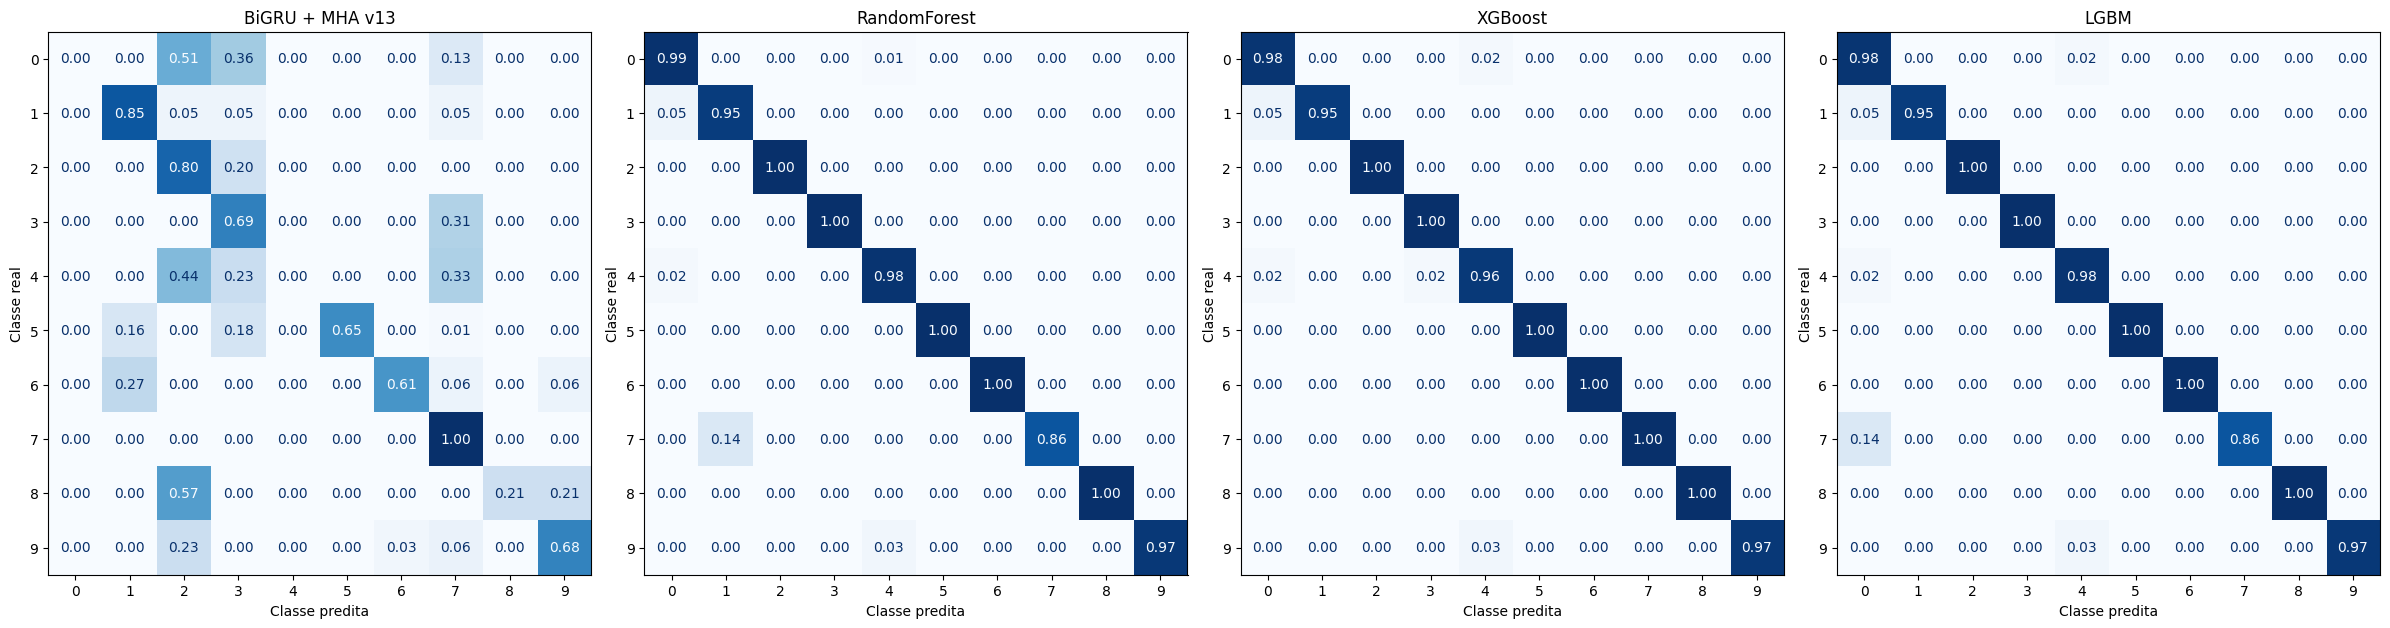

In [7]:
model_specs = [
    ('BiGRU + MHA v13', bigru_test_pred),
    ('RandomForest', rf_test_pred),
]
if xgb_test_eval is not None:
    model_specs.append(('XGBoost', xgb_test_pred))
if lgbm_test_eval is not None:
    model_specs.append(('LGBM', lgbm_test_pred))

fig, axes = plt.subplots(1, len(model_specs), figsize=(6 * len(model_specs), 6))
if len(model_specs) == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, model_specs):
    plot_confusion_matrix_for_predictions(
        test_arrays['y'],
        y_pred,
        bundle.class_labels,
        normalize='true',
        title=model_name,
        ax=ax,
    )

plt.tight_layout()
plt.show()

